# 🧠 04 · e-prop — 지역·온라인으로 계산하는 gradient

지역 3인자 학습에서 세 번째 인자가 **스칼라 보상 하나**이면, 깊은/많은 뉴런에서 "각 뉴런이 최종 오차에 *얼마나* 기여했나"라는 정교한 credit을 주기 어렵습니다.

**e-prop**(Bellec et al., 2020)의 아이디어: eligibility trace(자격 흔적, 지역적으로 계산되는 pre×post 흔적)는 유지하되, 세 번째 인자를 **과제 오차로부터 유도한 뉴런별 learning signal** $L_j^t$로 바꿉니다. 그러면 전체 gradient가 이렇게 분해됩니다:

$$ \frac{dE}{dW_{ji}} = \sum_t \underbrace{L_j^t}_{\text{③ 학습 신호}} \cdot \underbrace{e_{ji}^t}_{\text{①×② 자격 흔적}} $$

- $E$: 과제 손실(오차), $W_{ji}$: 뉴런 $j$의 입력 시냅스 $i$의 가중치, $t$: 시간 스텝.
- $e_{ji}^t$: **순방향으로** 계산되는 지역 자격 흔적 (과거를 저장하지 않음).
- $L_j^t$: 출력 오차를 readout으로 되쏘아 만든 신호 (시간 역방향 패스 아님).

## 이번 편의 핵심 주장
**e-prop = BPTT의 지역·온라인 근사.** BPTT처럼 시간축을 되감지 않고, 각 시냅스가 자기 주변 정보만으로 계산하는데도 그 가중치 갱신 방향이 **BPTT와 거의 일치**합니다. 이걸 직접 숫자로 확인합니다(cosine similarity).

## 이번 편 학습 목표
1. **BPTT**가 무엇을 하는지, 왜 비지역·오프라인인지 이해 (autograd 한 줄).
2. **e-prop**을 손으로 구현: eligibility trace × learning signal, **순방향·지역**.
3. e-prop gradient가 BPTT gradient와 **정렬**됨을 확인하고, e-prop만으로 SNN 분류기를 학습.

In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt

torch.manual_seed(0); np.random.seed(0)
plt.rcParams["font.family"] = "AppleGothic"
plt.rcParams["axes.unicode_minus"] = False
plt.rcParams["figure.figsize"] = (9, 3.2)
plt.rcParams["axes.grid"] = True
device = torch.device("cpu")

# --- 네트워크/뉴런 설정 ---
n_in, H, C = 30, 50, 3        # 입력 / 은닉 LIF / 클래스
T = 40                        # 시간 스텝
alpha, v_th, gamma = 0.9, 1.0, 0.3   # 막전위 감쇠, 임계값, surrogate 크기
print("SNN:", n_in, "->", H, "(LIF) ->", C, "| T =", T)

SNN: 30 -> 50 (LIF) -> 3 | T = 40


## 1. 스파이크의 미분 불가 문제와 surrogate gradient

스파이크 $z = H(v - v_{th})$($H$는 계단함수, $v$는 막전위, $v_{th}$는 임계값)는 미분이 0 또는 ∞라 gradient가 흐르지 않습니다. 해결책은 **역방향에서만** 매끈한 가짜 미분(pseudo-derivative/surrogate)을 쓰는 것:

$$ \psi_j^t = \gamma \cdot \max\!\Big(0,\; 1 - \frac{|v_j^t - v_{th}|}{v_{th}}\Big) \quad(\text{삼각형 surrogate}) $$

여기서 $\psi_j^t$는 뉴런 $j$의 시각 $t$에서의 가짜 미분, $\gamma$는 그 크기(스케일)입니다. 이 $\psi$는 **BPTT와 e-prop 둘 다에서** 쓰입니다 — e-prop은 이 $\psi$를 아래 eligibility trace 계산에 사용합니다.

아래는 forward는 계단함수, backward는 $\psi$를 흘리는 커스텀 autograd 함수입니다.

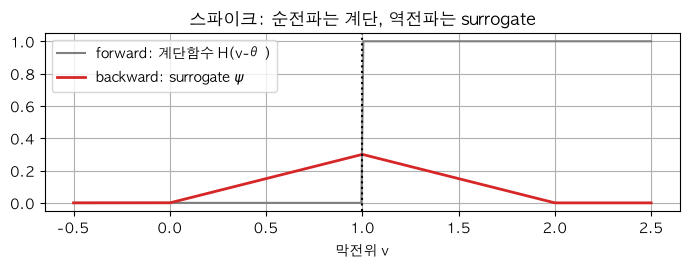

In [2]:
class SpikeFn(torch.autograd.Function):
    @staticmethod
    def forward(ctx, v):
        ctx.save_for_backward(v)
        return (v >= v_th).float()          # 순전파: 계단함수
    @staticmethod
    def backward(ctx, g):
        (v,) = ctx.saved_tensors
        psi = gamma*torch.clamp(1 - torch.abs(v - v_th)/v_th, min=0)  # 역전파: 삼각 surrogate
        return g*psi
spike = SpikeFn.apply

# surrogate 모양 시각화
vv = torch.linspace(-0.5, 2.5, 300)
psi = gamma*torch.clamp(1 - torch.abs(vv - v_th)/v_th, min=0)
fig, ax = plt.subplots(figsize=(7,2.8))
ax.plot(vv, (vv>=v_th).float(), color="tab:gray", label="forward: 계단함수 H(v-θ)")
ax.plot(vv, psi, color="tab:red", lw=2, label=r"backward: surrogate $\psi$")
ax.axvline(v_th, ls=":", c="k"); ax.set_xlabel("막전위 v"); ax.set_title("스파이크: 순전파는 계단, 역전파는 surrogate")
ax.legend(); plt.tight_layout(); plt.show()

## 2. 과제와 forward pass

간단한 **3-클래스 스파이크 패턴 분류**: 클래스 $c$면 입력의 $c$번째 1/3 그룹이 포아송 발화합니다. readout은 은닉 스파이크를 시간에 걸쳐 적분해 로짓을 만듭니다.

forward 루프에서 e-prop에 필요한 세 가지를 함께 기록합니다:
- **eligibility vector** $\varepsilon_i^t = \alpha\,\varepsilon_i^{t-1} + x_i^t$ — presynaptic 스파이크 $x_i^t$의 저역통과 흔적 ($\alpha$는 막전위 감쇠 계수). 입력 시냅스에선 이 값이 뒤쪽 뉴런 $j$와 무관합니다.
- **pseudo-derivative** $\psi_j^t$.
- 은닉 스파이크 $z_j^t$ (readout 학습용).

In [3]:
def gen_batch(B):
    y = torch.randint(0, C, (B,))
    x = torch.zeros(T, B, n_in)
    per = n_in // C
    for b in range(B):
        c = y[b].item()
        x[:, b, c*per:(c+1)*per] = (torch.rand(T, per) < 0.5).float()
    return x, y

def forward_full(x, W_in, W_out):
    # autograd 가능한 forward. logits + e-prop 중간값(psi, eps, z) 반환.
    B = x.shape[1]
    v = torch.zeros(B, H); z = torch.zeros(B, H); out = torch.zeros(B, C)
    eps = torch.zeros(B, n_in)
    psi_rec, eps_rec, z_rec = [], [], []
    for t in range(T):
        I = x[t] @ W_in.t()
        v = alpha*v + I - z*v_th        # LIF (soft reset)
        z = spike(v)
        out = out + z @ W_out.t()        # readout: 은닉 스파이크 적분
        with torch.no_grad():            # e-prop 중간값 (autograd와 분리 기록)
            psi = gamma*torch.clamp(1 - torch.abs(v - v_th)/v_th, min=0)
            eps = alpha*eps + x[t]
            psi_rec.append(psi.clone()); eps_rec.append(eps.clone()); z_rec.append(z.detach().clone())
    return out / T, psi_rec, eps_rec, z_rec

x, y = gen_batch(4)
logits, *_ = forward_full(x, torch.rand(H,n_in)*0.3, torch.rand(C,H)*0.3-0.15)
print("logits shape:", tuple(logits.shape), "(batch x class)")

logits shape: (4, 3) (batch x class)


## 3. BPTT — e-prop이 근사하는 기준

BPTT(Backpropagation Through Time)는 위 forward 그래프를 **시간축으로 다 펼친 뒤 끝에서부터 gradient를 역방향으로** 흘립니다. PyTorch autograd로는 `loss.backward()` 한 줄입니다.

하지만 이게 뉴로모픽 관점에서 불편한 이유:
- **오프라인**: 시퀀스가 끝나야 backward 시작 (온라인 아님).
- **전체 히스토리 저장**: 모든 시점의 활성값을 메모리에 들고 있어야 함.
- **비지역(weight transport)**: gradient가 순전파와 같은 가중치를 거꾸로 타고 흘러야 함 — 생물학적으로 구현 곤란.

e-prop은 **같은 gradient를 순방향·지역적으로** 만들어 이 셋을 모두 피합니다. 먼저 BPTT gradient를 기준값으로 구해둡니다.

In [4]:
W_in0  = torch.rand(H, n_in)*0.3
W_out0 = torch.rand(C, H)*0.3 - 0.15
x, y = gen_batch(128)

Wi = W_in0.clone().requires_grad_(True)
Wo = W_out0.clone().requires_grad_(True)
logits, *_ = forward_full(x, Wi, Wo)
loss = torch.nn.functional.cross_entropy(logits, y)
loss.backward()                              # ★ BPTT (autograd 한 줄)
gWin_bptt, gWout_bptt = Wi.grad.clone(), Wo.grad.clone()
print("BPTT gradient 계산 완료. |gW_in| =", round(gWin_bptt.norm().item(), 4))

BPTT gradient 계산 완료. |gW_in| = 0.2635


## 4. e-prop — 순방향·지역으로 같은 gradient 만들기

이제 backward 없이, forward에서 기록한 것들만으로 gradient를 조립합니다:

1. **학습 신호** $L_j = \sum_k W^{out}_{kj}\,(\pi_k - y^*_k)$ — 출력 오차를 readout 가중치로 되쏨(순간적 사영, 시간 역방향 아님). 여기서 $\pi_k$는 softmax 출력 확률, $y^*_k$는 정답 원-핫, $W^{out}$은 readout(출력층) 가중치입니다.
2. **은닉 자격 흔적** $\sum_t e_{ji}^t = \sum_t \psi_j^t\,\varepsilon_i^t$ (앞서의 pseudo-derivative $\psi$ × eligibility vector $\varepsilon$).
3. **gradient** $\;\dfrac{dE}{dW_{ji}} = \dfrac1T\sum_t L_j\,e_{ji}^t$.

그리고 BPTT gradient와 **cosine similarity**로 비교합니다.

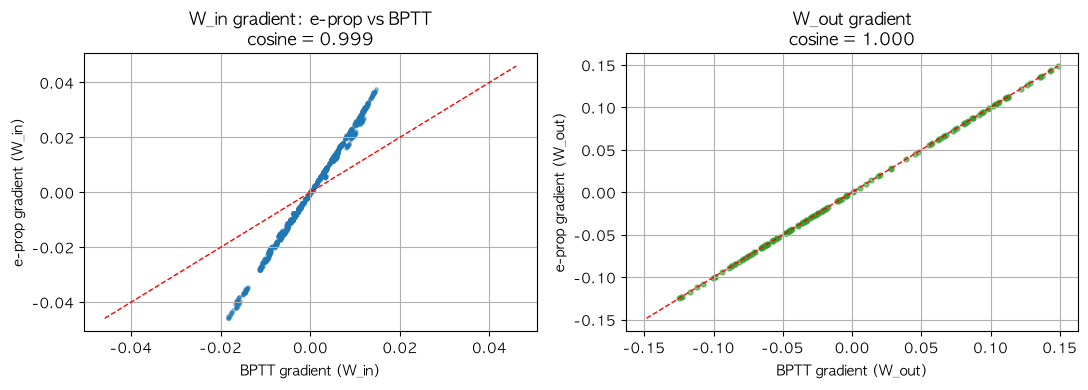

cosine similarity — W_in: 0.999  W_out: 1.000
=> 시간 역방향 없이, 지역·순방향으로 계산했는데 BPTT와 거의 같은 방향!


In [5]:
def eprop_grads(x, y, W_in, W_out):
    B = x.shape[1]
    logits, psi_rec, eps_rec, z_rec = forward_full(x, W_in.detach(), W_out.detach())
    pi = torch.softmax(logits, dim=1)
    onehot = torch.zeros(B, C); onehot[torch.arange(B), y] = 1.0
    err = (pi - onehot) / B                       # 출력 오차 [B,C]
    L = err @ W_out.detach()                       # ③ 학습 신호 [B,H]
    E = torch.zeros(B, H, n_in)                     # sum_t psi*eps
    for t in range(T):
        E += psi_rec[t].unsqueeze(2) * eps_rec[t].unsqueeze(1)
    gW_in  = (L.unsqueeze(2) * E).sum(0) / T        # [H,n_in]
    gW_out = err.t() @ torch.stack(z_rec).mean(0)   # [C,H]
    return gW_in, gW_out

gWin_ep, gWout_ep = eprop_grads(x, y, W_in0, W_out0)

def cos(a, b):
    a=a.flatten(); b=b.flatten(); return float((a@b)/(a.norm()*b.norm()+1e-9))
c_in, c_out = cos(gWin_ep, gWin_bptt), cos(gWout_ep, gWout_bptt)

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].scatter(gWin_bptt.flatten(), gWin_ep.flatten(), s=6, alpha=0.4, color="tab:blue")
lim = max(gWin_bptt.abs().max(), gWin_ep.abs().max()).item()
ax[0].plot([-lim,lim],[-lim,lim], "r--", lw=1)
ax[0].set_xlabel("BPTT gradient (W_in)"); ax[0].set_ylabel("e-prop gradient (W_in)")
ax[0].set_title(f"W_in gradient: e-prop vs BPTT\ncosine = {c_in:.3f}")
ax[1].scatter(gWout_bptt.flatten(), gWout_ep.flatten(), s=12, alpha=0.6, color="tab:green")
lim2 = max(gWout_bptt.abs().max(), gWout_ep.abs().max()).item()
ax[1].plot([-lim2,lim2],[-lim2,lim2], "r--", lw=1)
ax[1].set_xlabel("BPTT gradient (W_out)"); ax[1].set_ylabel("e-prop gradient (W_out)")
ax[1].set_title(f"W_out gradient\ncosine = {c_out:.3f}")
plt.tight_layout(); plt.show()
print(f"cosine similarity — W_in: {c_in:.3f}  W_out: {c_out:.3f}")
print("=> 시간 역방향 없이, 지역·순방향으로 계산했는데 BPTT와 거의 같은 방향!")

> **정직한 주석**: 여기 cosine이 ~1.0인 건 이 네트워크가 **얕은 feedforward**(은닉 1층)라 e-prop이 생략하는 항(리셋·순환 Jacobian)이 작기 때문입니다. **순환 연결**(hidden→hidden)이나 **긴 시간의존성**이 생기면 e-prop은 진짜 *근사*가 되어 정렬도가 내려갑니다 — 그래도 학습은 잘 됩니다. (아래 '실험'에서 순환 항을 넣어 정렬도가 떨어지는 걸 볼 수 있습니다.)

## 5. e-prop만으로 학습하기

BPTT/autograd 없이, 위 e-prop gradient로 경사하강해 분류기를 학습합니다.

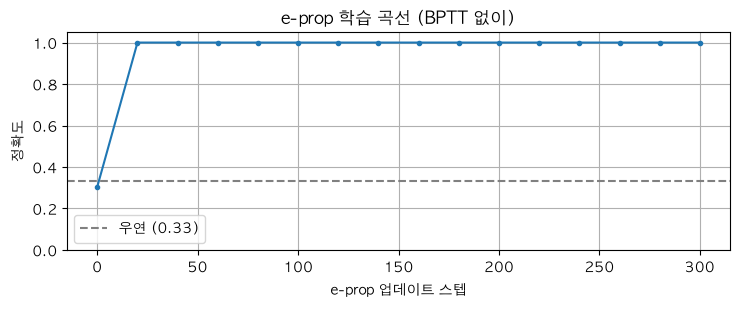

최종 정확도: 1.00


In [6]:
def evaluate(W_in, W_out, B=400):
    xv, yv = gen_batch(B)
    logits, *_ = forward_full(xv, W_in, W_out)
    return (logits.argmax(1) == yv).float().mean().item()

W_in  = torch.rand(H, n_in)*0.3
W_out = torch.rand(C, H)*0.3 - 0.15
lr = 0.5
acc_hist = [(0, evaluate(W_in, W_out))]
for step in range(1, 301):
    xb, yb = gen_batch(64)
    gWin, gWout = eprop_grads(xb, yb, W_in, W_out)
    W_in  -= lr*gWin
    W_out -= lr*gWout
    if step % 20 == 0:
        acc_hist.append((step, evaluate(W_in, W_out)))

xs = [a[0] for a in acc_hist]; ys = [a[1] for a in acc_hist]
fig, ax = plt.subplots(figsize=(7.5,3.2))
ax.plot(xs, ys, marker="o", ms=3, color="tab:blue")
ax.axhline(1/3, ls="--", c="gray", label="우연 (0.33)")
ax.set_ylim(0,1.05); ax.set_xlabel("e-prop 업데이트 스텝"); ax.set_ylabel("정확도")
ax.set_title("e-prop 학습 곡선 (BPTT 없이)"); ax.legend()
plt.tight_layout(); plt.show()
print(f"최종 정확도: {ys[-1]:.2f}")

## 6. 정리 & 다음 단계

### 배운 것
- **surrogate gradient** $\psi$는 스파이크의 미분 불가를 우회 — **BPTT와 e-prop 둘 다** 사용.
- **e-prop**: $\dfrac{dE}{dW_{ji}}=\sum_t L_j^t e_{ji}^t$. 자격 흔적(지역·순방향) × 학습 신호(오차 사영). **시간 역방향·전체 저장·weight transport 불필요.**
- 실측: e-prop gradient가 **BPTT와 cosine ≈ 1** (얕은 net). e-prop만으로 학습 성공.
- 스칼라 보상에서 **뉴런별 학습 신호**로 세 번째 인자가 정교해졌고, **eligibility trace가 STDP·R-STDP·e-prop을 관통하는 한 줄기**임을 확인.

### 직접 바꿔보면 좋은 것
- **순환 연결 추가**: 은닉층에 `W_rec` (hidden→hidden)를 넣고 forward에 `+ z_prev @ W_rec.t()`를 더해보기. e-prop 자격 흔적은 그대로 두고 BPTT와의 cosine이 얼마나 떨어지는지 → **근사의 한계** 체감.
- `T`를 `100`으로 늘려 긴 시간의존성에서 정렬도 변화 관찰.
- `gamma`(surrogate 크기)를 바꿔 학습 안정성 확인.

### 다음 편(`05`) — Predictive Coding, 그리고 JEPA로 가는 다리
지금까지는 보상/오차라는 명시적 신호로 배웠습니다. 다음 편은 신호의 출처를 바꿉니다: **위 층이 아래 층을 예측하고, 그 예측 오차로 지역 학습**하는 **predictive coding**. BPTT가 필요 없는 또 다른 지역 학습이며, **latent 공간에서 표현을 예측하는 JEPA와 개념적으로 이어지는** 지점입니다.